In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# K-Nearest Neighbors Classifier
from sklearn.neighbors import KNeighborsClassifier

# Split dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Feature scaling (Standardization)
from sklearn.preprocessing import StandardScaler

# Model evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

In [2]:
"""
Label Encoding (Used in categorical Columns)
-------------------
-> Convert alphabetical data into numeric data

1. Label Encoder -> Used for data which can be compared
2. One-Hot Encoder -> Used for data which cannot be compared
	-> It only contains binary value (0 (No) and 1 (Yes))
    """

'\nLabel Encoding (Used in categorical Columns)\n-------------------\n-> Convert alphabetical data into numeric data\n\n1. Label Encoder -> Used for data which can be compared\n2. One-Hot Encoder -> Used for data which cannot be compared\n\t-> It only contains binary value (0 (No) and 1 (Yes))\n    '

In [3]:
df=pd.read_csv('Dataset/student.csv')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,higher education,higher education,at_home,teacher,...,very good,medium,high,very low,very low,good,6,5,6,6
1,GP,F,17,U,GT3,T,primary education (4th grade),primary education (4th grade),at_home,other,...,excellent,medium,medium,very low,very low,good,4,5,5,6
2,GP,F,15,U,LE3,T,primary education (4th grade),primary education (4th grade),at_home,other,...,very good,medium,low,low,medium,good,10,7,8,10
3,GP,F,15,U,GT3,T,higher education,5th to 9th grade,health,services,...,good,low,low,very low,very low,excellent,2,15,14,15
4,GP,F,16,U,GT3,T,secondary education,secondary education,other,other,...,very good,medium,low,very low,low,excellent,4,6,10,10


In [4]:
df['G3'].sort_values(ascending=True).unique()

array([ 0,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
       20])

In [5]:
def convertMarks(marks):
    if marks >= 17 and marks <= 20:
        return 'A'
    elif marks >= 13 and marks < 17:
        return 'B'
    elif marks >= 8 and marks < 13:
        return 'C'
    elif marks >= 0 and marks < 8:
        return 'Fail'
    else:
        return 'invalid marks to grade'

In [6]:
df['Grade']=df['G3'].apply(convertMarks)

In [7]:
df['Grade'].value_counts()

Grade
C       194
B       107
Fail     70
A        24
Name: count, dtype: int64

In [8]:
df['Medu'].unique()

array(['higher education', 'primary education (4th grade)',
       'secondary education', '5th to 9th grade', 'none'], dtype=object)

In [9]:
m_f_edu = {
    'none': 0,
    'primary education (4th grade)': 1,
    '5th to 9th grade': 2,
    'secondary education': 3,
    'higher education': 4
}

columns = ['Medu', 'Fedu']

for col in columns:
    df[f'{col}_id'] = df[col].map(m_f_edu)

In [10]:
df['traveltime'].unique()

array(['15 to 30 min.', '<15 min.', '30 min. to 1 hour', '>1 hour'],
      dtype=object)

In [11]:
tt_id={
    '<15 min.':0,
    '15 to 30 min.':1,
    '30 min. to 1 hour':2,
    '>1 hour':3  
}
df['traveltime_id']=df['traveltime'].map(tt_id)

In [12]:
df['studytime'].unique()

array(['2 to 5 hours', '5 to 10 hours', '<2 hours', '>10 hours'],
      dtype=object)

In [13]:
# Function to perform label encoding on a categorical column
def labelEncodeData(dataframe, col_name, *args):

    # Create an empty dictionary to store category-to-number mappings
    encoding_val = {}

    # Assign a unique integer to each category
    for idx, val in enumerate(args):
        encoding_val[val] = idx

    # Create a new column with "_id" suffix and map categories to numbers
    dataframe[f'{col_name}_id'] = dataframe[col_name].map(encoding_val)

   

In [14]:
labelEncodeData(
    df,
    'studytime',
    '<2 hours',
    '2 to 5 hours',
    '5 to 10 hours',
    '>10 hours'
)


In [15]:
labelEncodeData(
    df,
    'schoolsup','no','yes'  
)

In [16]:
labelEncodeData(
    df,
    'famsup','no','yes'  
)

In [17]:
labelEncodeData(
    df,
    'internet','no','yes'  
)

In [18]:
labelEncodeData(
    df,
    'internet','no','yes'  
)

In [19]:

labelEncodeData(
   df,
   'freetime','very low', 'low','medium','high','very high'
)

In [20]:

labelEncodeData(
   df,
   'goout','very low', 'low','medium','high','very high'
)

In [21]:


labelEncodeData(
   df,
   'Dalc','very low', 'low','medium','high','very high'
)


In [22]:

labelEncodeData(
   df,
   'Walc','very low', 'low','medium','high','very high'
)

In [23]:
labelEncodeData(
    df,
    'health',
    'very bad',
    'bad',
    'good',
    'very good',
    'excellent'
)

In [24]:
labelEncodeData(
    df,
    'Grade',
    'Fail',
    'C',
    'B',
    'A'
)

In [25]:
#df.info()

In [26]:
df_sample = df.select_dtypes(include='int64')
df_sample = df_sample.drop(columns=['age', 'G3'])
                         

In [27]:
df_sample

,failures,absences,G1,G2,Medu_id,Fedu_id,traveltime_id,studytime_id,schoolsup_id,famsup_id,internet_id,freetime_id,goout_id,Dalc_id,Walc_id,health_id,Grade_id
0,0,6,5,6,4,4,1,1,1,0,0,2,3,0,0,2,0
1,0,4,5,5,1,1,0,1,0,1,1,2,2,0,0,2,0
2,3,10,7,8,1,1,0,1,1,0,1,2,1,1,2,2,1
3,0,2,15,14,4,2,0,2,0,1,1,1,1,0,0,4,2
4,0,4,6,10,3,3,0,1,0,1,0,2,1,0,1,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,2,11,9,9,2,2,0,1,0,1,0,4,3,3,4,3,1
391,0,3,14,16,3,1,1,0,0,0,1,3,4,2,3,1,2
392,3,3,10,8,1,1,0,0,0,0,0,4,2,2,2,2,0
393,0,0,11,12,3,2,2,0,0,0,1,3,0,2,3,4,1


In [28]:
df_sample.columns

Index(['failures', 'absences', 'G1', 'G2', 'Medu_id', 'Fedu_id',
       'traveltime_id', 'studytime_id', 'schoolsup_id', 'famsup_id',
       'internet_id', 'freetime_id', 'goout_id', 'Dalc_id', 'Walc_id',
       'health_id', 'Grade_id'],
      dtype='object')

In [29]:
features = [
    'failures', 'absences', 'G1', 'G2',
    'Medu_id', 'Fedu_id',
    'traveltime_id', 'studytime_id',
    'schoolsup_id', 'famsup_id',
    'internet_id', 'freetime_id',
    'goout_id', 'Dalc_id', 'Walc_id',
    'health_id'
]

target = 'Grade_id'

In [30]:
X=df_sample[features]
Y=df_sample[target]

In [31]:
# Split the dataset into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,                 # Features (X) and target variable (Y)
    test_size=0.2,        # Use 20% of the data for testing and 80% for training
    random_state=42,      # Set a random seed for reproducible results
    stratify=Y            # Preserve the same class distribution in both training and testing sets
)

In [32]:
smote=SMOTE(random_state=42)
X_train_balanced,Y_train_balanced=smote.fit_resample(X_train,Y_train)

In [33]:
#(xi-mean)/sd

scaler = StandardScaler()

In [34]:
#fit_transform->feature training->fit(learning) transform(implement)
#transform(implementation)->features testing
X_train_scale = scaler.fit_transform(X_train_balanced)
X_test_scale = scaler.transform(X_test)

Elbow method

In [35]:
# Try K values from 1 to 20
k_range = range(1, 21)

# Create an empty list to store the error rate for each K
error_rate = []

In [36]:

# Loop through each K value
for i in k_range:

    # Create a KNN classifier with K = i
    knn = KNeighborsClassifier(n_neighbors=i)

    # Train the model using the training data
    knn.fit(X_train_scale, Y_train_balanced)

    # Predict the test data
    knn_pred = knn.predict(X_test_scale)

    # Calculate the error rate and store it in the list
    error_rate.append(np.mean(Y_test != knn_pred))

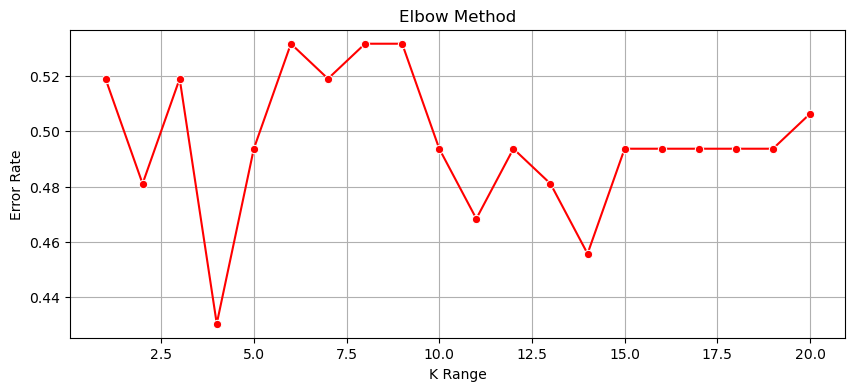

In [37]:
plt.figure(figsize=(10, 4))

sns.lineplot(x=k_range, y=error_rate, color='red', marker='o')

plt.grid()
plt.xlabel('K Range')
plt.ylabel('Error Rate')
plt.title('Elbow Method')
plt.show()

In [38]:
# Choose the value of K
k = 5

# Create the KNN model
model = KNeighborsClassifier(n_neighbors=k)

# Train the model using the training data
model.fit(X_train_scale, Y_train_balanced)

# Predict the test data
Y_pred = model.predict(X_test_scale)


In [41]:
Y_pred

array([0, 1, 3, 2, 2, 0, 1, 2, 2, 0, 0, 2, 3, 1, 1, 2, 1, 1, 1, 3, 3, 0,
       1, 1, 0, 0, 2, 0, 1, 2, 2, 2, 1, 1, 1, 2, 0, 3, 1, 2, 1, 0, 2, 1,
       1, 2, 1, 3, 0, 1, 1, 0, 3, 1, 1, 0, 2, 1, 2, 0, 1, 1, 2, 1, 1, 0,
       0, 1, 0, 3, 2, 0, 1, 2, 1, 2, 2, 0, 0])

In [39]:

cr = classification_report(Y_test, Y_pred)
cm = confusion_matrix(Y_test, Y_pred)

In [40]:
print(cr)

              precision    recall  f1-score   support

           0       0.45      0.64      0.53        14
           1       0.63      0.49      0.55        39
           2       0.43      0.43      0.43        21
           3       0.38      0.60      0.46         5

    accuracy                           0.51        79
   macro avg       0.47      0.54      0.49        79
weighted avg       0.53      0.51      0.51        79



<Axes: >

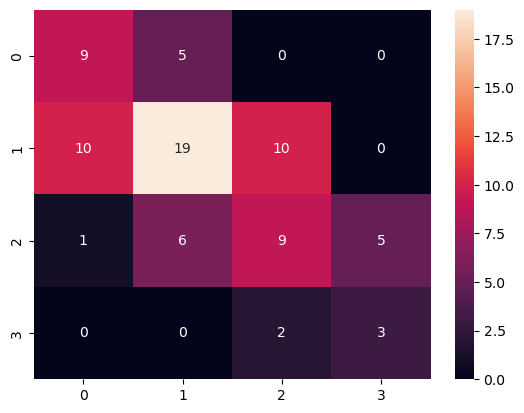

In [48]:
sns.heatmap(cm,annot=True)

SVM implementation

In [56]:
from sklearn.svm import SVC

In [57]:
svm_model=SVC(kernel='linear')

In [58]:
svm_model.fit(X_train_scale, Y_train_balanced)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [59]:
svm_pred=svm_model.predict(X_test_scale)

In [60]:
svm_cr = classification_report(Y_test,svm_pred )
scm_cm= confusion_matrix(Y_test,svm_pred )

In [61]:
print(svm_cr)

              precision    recall  f1-score   support

           0       0.69      0.64      0.67        14
           1       0.81      0.77      0.79        39
           2       0.77      0.81      0.79        21
           3       0.71      1.00      0.83         5

    accuracy                           0.77        79
   macro avg       0.75      0.81      0.77        79
weighted avg       0.77      0.77      0.77        79



In [62]:
print(scm_cm)

[[ 9  5  0  0]
 [ 4 30  5  0]
 [ 0  2 17  2]
 [ 0  0  0  5]]
